## Housing returns analysis

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw"
DERIVED = ROOT / "data" / "derived"
OUTPUTS = ROOT / "outputs"


## Sources and annual panel

In [3]:
hpi = pd.read_csv(
    RAW / "fhfa" / "hpi_at_metro.csv",
    header=None,
    names=["metro", "cbsa", "year", "quarter", "hpi", "se"],
    na_values="-",
)
hpi["cbsa"] = hpi["cbsa"].astype("Int64")
hpi["se"] = hpi["se"].str.strip("()").astype(float)
hpi = hpi.dropna(subset=["hpi"]).copy()

# FHFA publishes selected large metros as metropolitan divisions.
hpi_divisions = pd.read_excel(
    RAW / "fhfa" / "hpi_at_multid_metro.xlsx",
    header=3,
    names=["cbsa", "metro", "year", "quarter", "hpi"],
)
hpi_msa = hpi[~hpi["metro"].str.contains("MSAD", case=False, na=False)].copy()
hpi_analysis = pd.concat([hpi_msa, hpi_divisions], ignore_index=True)

hpi_annual = (
    hpi_analysis.groupby(["cbsa", "year"], as_index=False)["hpi"]
    .mean()
    .sort_values(["cbsa", "year"])
)
hpi_annual["hpi_yoy"] = hpi_annual.groupby("cbsa")["hpi"].pct_change(fill_method=None)


In [4]:
acs = pd.read_csv(DERIVED / "acs_market_panel_2005_2024.csv")
acs = acs[acs["name"].str.endswith("Metro Area")].copy()
acs = acs.sort_values(["cbsa", "year"])
acs["households"] = acs["occupied_housing_units"]
acs["previous_year"] = acs.groupby("cbsa")["year"].shift()
acs["household_growth"] = acs.groupby("cbsa")["households"].pct_change(fill_method=None)
acs["housing_unit_growth"] = acs.groupby("cbsa")["housing_units"].pct_change(fill_method=None)

# Do not treat gaps or CBSA delineation changes as annual growth.
nonconsecutive = acs["year"] - acs["previous_year"] != 1
delineation_year = acs["year"].isin([2013, 2019, 2023])
acs.loc[nonconsecutive | delineation_year, ["household_growth", "housing_unit_growth"]] = np.nan

bls = pd.read_csv(DERIVED / "bls_metro_wages_2005_2025.csv")
bls["metro"] = bls["AREA_TITLE"].fillna(bls["AREA_NAME"])


In [5]:
panel = acs.merge(
    hpi_annual[["cbsa", "year", "hpi", "hpi_yoy"]],
    on=["cbsa", "year"],
    how="left",
    validate="one_to_one",
)
panel_clean = panel[panel["hpi"].notna()].copy()

print(f"ACS metro rows: {len(acs):,}")
print(f"Matched panel rows: {len(panel_clean):,}")
print(f"Missing HPI share: {panel['hpi'].isna().mean():.1%}")


ACS metro rows: 7,261
Matched panel rows: 6,822
Missing HPI share: 6.0%


## Exploration

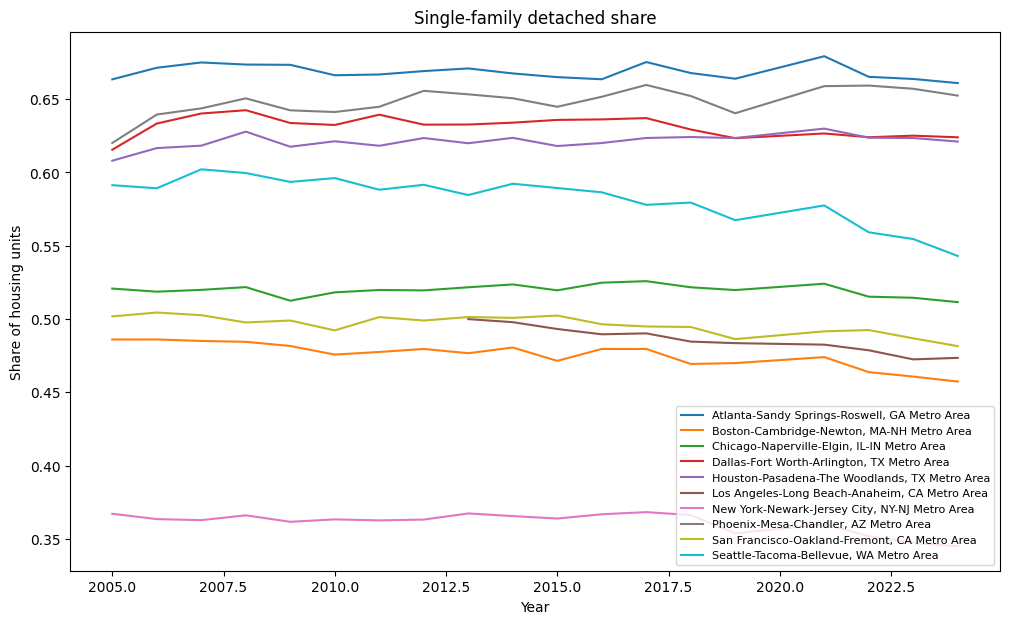

In [6]:
def plot_metros(frame, cbsas, x, y, title, ylabel):
    subset = frame[frame["cbsa"].isin(cbsas)]
    plt.figure(figsize=(12, 7))
    for _, group in subset.groupby("cbsa"):
        plt.plot(group[x], group[y], label=group["name"].iloc[-1])
    plt.title(title)
    plt.xlabel(x.replace("_", " ").title())
    plt.ylabel(ylabel)
    plt.legend(fontsize=8)
    plt.show()


comparison_cbsas = [31080, 41860, 35620, 14460, 16980, 26420, 19100, 12060, 38060, 42660]
plot_metros(
    panel_clean,
    comparison_cbsas,
    "year",
    "share_sf_detached",
    "Single-family detached share",
    "Share of housing units",
)


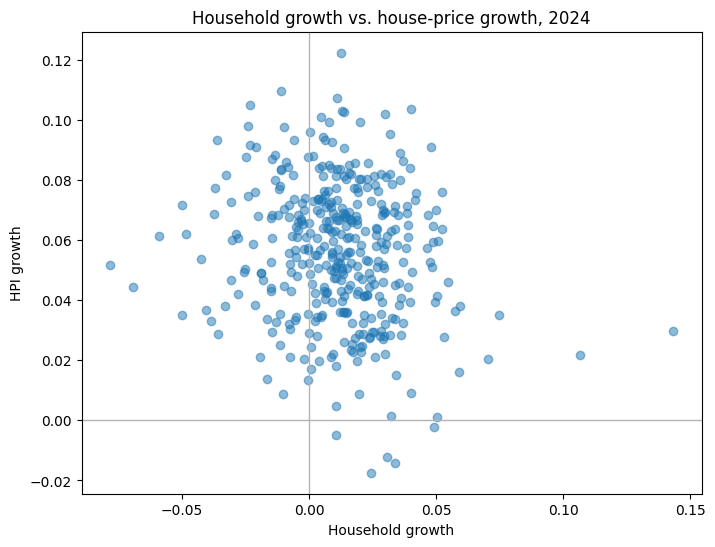

In [7]:
year_df = panel_clean[panel_clean["year"] == 2024]
plt.figure(figsize=(8, 6))
plt.scatter(year_df["household_growth"], year_df["hpi_yoy"], alpha=0.5)
plt.axhline(0, color="0.7", linewidth=1)
plt.axvline(0, color="0.7", linewidth=1)
plt.xlabel("Household growth")
plt.ylabel("HPI growth")
plt.title("Household growth vs. house-price growth, 2024")
plt.show()


## Fixed-effects models

In [8]:
model_df = panel_clean.dropna(
    subset=["hpi_yoy", "household_growth", "share_sf_detached", "housing_unit_growth", "vacancy_rate"]
).copy()
model_df["sf_centered"] = model_df["share_sf_detached"] - model_df["share_sf_detached"].mean()

def compact_model_table(models, terms):
    # Show substantive coefficients only; fixed-effect dummies stay hidden.
    rows = []
    for name, model in models.items():
        for term in terms:
            if term in model.params:
                rows.append(
                    {
                        "model": name,
                        "term": term,
                        "coefficient": model.params[term],
                        "standard_error": model.bse[term],
                        "p_value": model.pvalues[term],
                        "r_squared": model.rsquared,
                        "n": int(model.nobs),
                    }
                )
    return pd.DataFrame(rows)

hpi_model = smf.ols(
    "hpi_yoy ~ household_growth * sf_centered + C(year) + C(cbsa)",
    data=model_df,
).fit(cov_type="cluster", cov_kwds={"groups": model_df["cbsa"]})

supply_model = smf.ols(
    "housing_unit_growth ~ household_growth + C(year)",
    data=model_df,
).fit(cov_type="cluster", cov_kwds={"groups": model_df["cbsa"]})

year_only = smf.ols("hpi_yoy ~ C(year)", data=model_df).fit()
year_plus_x = smf.ols(
    "hpi_yoy ~ household_growth * sf_centered + C(year)", data=model_df
).fit()
fe_only = smf.ols("hpi_yoy ~ C(year) + C(cbsa)", data=model_df).fit()
fe_plus_x = smf.ols(
    "hpi_yoy ~ household_growth * sf_centered + C(year) + C(cbsa)", data=model_df
).fit()

hpi_model_table = compact_model_table(
    {"fixed effects": hpi_model},
    ["household_growth", "sf_centered", "household_growth:sf_centered"],
)
fit_comparison = pd.DataFrame(
    {
        "model": ["year only", "year + variables", "year + metro FE", "FE + variables"],
        "r_squared": [year_only.rsquared, year_plus_x.rsquared, fe_only.rsquared, fe_plus_x.rsquared],
    }
)
fit_comparison["incremental_r_squared"] = fit_comparison["r_squared"].diff()

hpi_model_table, fit_comparison

(           model                          term  coefficient  standard_error  \
 0  fixed effects              household_growth     0.162950        0.029714   
 1  fixed effects                   sf_centered     0.135475        0.048696   
 2  fixed effects  household_growth:sf_centered    -0.906474        0.482551   
 
         p_value  r_squared     n  
 0  4.159257e-08   0.662635  4979  
 1  5.402010e-03   0.662635  4979  
 2  6.031218e-02   0.662635  4979  ,
               model  r_squared  incremental_r_squared
 0         year only   0.625486                    NaN
 1  year + variables   0.631432               0.005946
 2   year + metro FE   0.658049               0.026617
 3    FE + variables   0.662635               0.004586)

In [9]:
hpi_supply_model = smf.ols(
    "hpi_yoy ~ household_growth + housing_unit_growth + C(year)", data=model_df
).fit(cov_type="cluster", cov_kwds={"groups": model_df["cbsa"]})

supply_table = compact_model_table(
    {"supply response": supply_model, "HPI with supply": hpi_supply_model},
    ["household_growth", "housing_unit_growth"]
)

In [10]:
housing_unit_year_only = smf.ols(
    "housing_unit_growth ~ C(year)", data=model_df
).fit()
housing_unit_incremental_r2 = supply_model.rsquared - housing_unit_year_only.rsquared
housing_unit_partial_r2 = (
    housing_unit_year_only.ssr - supply_model.ssr
) / housing_unit_year_only.ssr

pd.DataFrame(
    {
        "year_only_r_squared": [housing_unit_year_only.rsquared],
        "full_r_squared": [supply_model.rsquared],
        "incremental_r_squared": [housing_unit_incremental_r2],
        "partial_r_squared": [housing_unit_partial_r2],
        "n": [int(supply_model.nobs)],
    },
    index=["housing_unit_growth ~ household_growth + C(year)"],
)


,year_only_r_squared,full_r_squared,incremental_r_squared,partial_r_squared,n
housing_unit_growth ~ household_growth + C(year),0.091488,0.300355,0.208867,0.2299,4979


In [14]:
hpi_hh_only = smf.ols(
    "hpi_yoy ~ household_growth + C(year)", data=model_df
).fit()
hpi_housing_unit_fit = pd.DataFrame(
    {
        "baseline_r_squared": [hpi_hh_only.rsquared],
        "full_r_squared": [hpi_supply_model.rsquared],
        "incremental_r_squared": [hpi_supply_model.rsquared - hpi_hh_only.rsquared],
        "partial_r_squared": [
            (hpi_hh_only.ssr - hpi_supply_model.ssr) / hpi_hh_only.ssr
        ],
        "n": [int(hpi_supply_model.nobs)],
    },
    index=["HPI: add housing-unit growth given household growth"],
)
hpi_housing_unit_fit


,baseline_r_squared,full_r_squared,incremental_r_squared,partial_r_squared,n
HPI: add housing-unit growth given household growth,0.631032,0.633104,0.002072,0.005617,4979


## vacancy-lag models

In [21]:
lag_df = panel_clean.sort_values(["cbsa", "year"]).copy()
lag_df["previous_year"] = lag_df.groupby("cbsa")["year"].shift()
lag_df["two_years_prior"] = lag_df.groupby("cbsa")["year"].shift(2)
lag_df["vacancy_lag1"] = lag_df.groupby("cbsa")["vacancy_rate"].shift(1)
lag_df["vacancy_lag2"] = lag_df.groupby("cbsa")["vacancy_rate"].shift(2)

lag_df.loc[lag_df["year"] - lag_df["previous_year"] != 1, "vacancy_lag1"] = np.nan
lag_df.loc[lag_df["year"] - lag_df["two_years_prior"] != 2, "vacancy_lag2"] = np.nan

delineation_breaks = {2010, 2013, 2019, 2023}
follows_delineation_break = lag_df["previous_year"].isin(delineation_breaks)
lag_df.loc[
    lag_df["year"].isin(delineation_breaks),
    ["household_growth", "housing_unit_growth"],
] = np.nan
lag_df.loc[follows_delineation_break, "vacancy_lag2"] = np.nan

lag_sample = lag_df.dropna(subset=["household_growth", "vacancy_lag1", "vacancy_lag2"]).copy()
vacancy_fe_only = smf.ols("household_growth ~ C(year) + C(cbsa)", data=lag_sample).fit()
vacancy_lag1_model = smf.ols(
    "household_growth ~ vacancy_lag1 + C(year) + C(cbsa)", data=lag_sample
).fit(cov_type="cluster", cov_kwds={"groups": lag_sample["cbsa"]})
vacancy_lag2_model = smf.ols(
    "household_growth ~ vacancy_lag2 + C(year) + C(cbsa)", data=lag_sample
).fit(cov_type="cluster", cov_kwds={"groups": lag_sample["cbsa"]})
vacancy_both_model = smf.ols(
    "household_growth ~ vacancy_lag1 + vacancy_lag2 + C(year) + C(cbsa)",
    data=lag_sample,
).fit(cov_type="cluster", cov_kwds={"groups": lag_sample["cbsa"]})

def partial_r_squared(base, full):
    return (base.ssr - full.ssr) / base.ssr

vacancy_table = compact_model_table(
    {"lag 1": vacancy_lag1_model, "lag 2": vacancy_lag2_model, "both lags": vacancy_both_model},
    ["vacancy_lag1", "vacancy_lag2"],
)
vacancy_table["partial_r_squared_vs_fe"] = [
    partial_r_squared(vacancy_fe_only, vacancy_lag1_model),
    partial_r_squared(vacancy_fe_only, vacancy_lag2_model),
    partial_r_squared(vacancy_fe_only, vacancy_both_model),
    partial_r_squared(vacancy_fe_only, vacancy_both_model),
]
vacancy_table

,model,term,coefficient,standard_error,p_value,r_squared,n,partial_r_squared_vs_fe
0,lag 1,vacancy_lag1,0.553442,0.081707,1.257335e-11,0.294177,2827,0.192451
1,lag 2,vacancy_lag2,0.068992,0.032528,3.391905e-02,0.128507,2827,0.002903
2,both lags,vacancy_lag1,0.688694,0.051850,2.922960e-40,0.325089,2827,0.227818
3,both lags,vacancy_lag2,-0.277186,0.052695,1.439080e-07,0.325089,2827,0.227818


In [24]:
vacancy_fit_comparison = pd.DataFrame(
    {
        "model": ["FE only", "lag 1", "lag 2", "both lags"],
        "r_squared": [
            vacancy_fe_only.rsquared,
            vacancy_lag1_model.rsquared,
            vacancy_lag2_model.rsquared,
            vacancy_both_model.rsquared,
        ],
        "incremental_r_squared_vs_fe": [
            0.0,
            vacancy_lag1_model.rsquared - vacancy_fe_only.rsquared,
            vacancy_lag2_model.rsquared - vacancy_fe_only.rsquared,
            vacancy_both_model.rsquared - vacancy_fe_only.rsquared,
        ],
        "partial_r_squared_vs_fe": [
            0.0,
            partial_r_squared(vacancy_fe_only, vacancy_lag1_model),
            partial_r_squared(vacancy_fe_only, vacancy_lag2_model),
            partial_r_squared(vacancy_fe_only, vacancy_both_model),
        ],
        "n": [int(vacancy_fe_only.nobs)] * 4,
    }
)
vacancy_fit_comparison

,model,r_squared,incremental_r_squared_vs_fe,partial_r_squared_vs_fe,n
0,FE only,0.125969,0.000000,0.000000,2827
1,lag 1,0.294177,0.168208,0.192451,2827
2,lag 2,0.128507,0.002537,0.002903,2827
3,both lags,0.325089,0.199120,0.227818,2827


## Vacancy reparameterization and trimming


In [27]:
lag_sample["vacancy_change"] = lag_sample["vacancy_lag1"] - lag_sample["vacancy_lag2"]
vacancy_change_model = smf.ols(
    "household_growth ~ vacancy_lag2 + vacancy_change + C(year) + C(cbsa)", data=lag_sample
).fit(cov_type="cluster", cov_kwds={"groups": lag_sample["cbsa"]})

vacancy_lo, vacancy_hi = lag_sample["vacancy_change"].quantile([0.01, 0.99])
growth_lo, growth_hi = lag_sample["household_growth"].quantile([0.01, 0.99])
trimmed_lag_sample = lag_sample[
    lag_sample["vacancy_change"].between(vacancy_lo, vacancy_hi)
    & lag_sample["household_growth"].between(growth_lo, growth_hi)
].copy()
trimmed_change_model = smf.ols(
    "household_growth ~ vacancy_lag2 + vacancy_change + C(year) + C(cbsa)", data=trimmed_lag_sample
).fit(cov_type="cluster", cov_kwds={"groups": trimmed_lag_sample["cbsa"]})

param = compact_model_table(
    {"full sample": vacancy_change_model, "trimmed sample": trimmed_change_model},
    ["vacancy_lag2", "vacancy_change"],
)
param

,model,term,coefficient,standard_error,p_value,r_squared,n
0,full sample,vacancy_lag2,0.411507,0.082453,6.012030e-07,0.325089,2827
1,full sample,vacancy_change,0.688694,0.051850,2.922960e-40,0.325089,2827
2,trimmed sample,vacancy_lag2,0.371498,0.077482,1.629927e-06,0.318182,2720
3,trimmed sample,vacancy_change,0.609084,0.046694,6.860585e-39,0.318182,2720


In [35]:
trimmed_lag2_model = smf.ols(
    "household_growth ~ vacancy_lag2 + C(year) + C(cbsa)", data=trimmed_lag_sample
).fit(cov_type="cluster", cov_kwds={"groups": trimmed_lag_sample["cbsa"]})

vacancy_fe_only = smf.ols("household_growth ~ C(year) + C(cbsa)", data=lag_sample).fit()
vacancy_fe_only_trimmed = smf.ols("household_growth ~ C(year) + C(cbsa)", data=trimmed_lag_sample).fit()

vacancy_change_fit_comparison = pd.DataFrame(
    {
        "sample": ["full", "trimmed"],
        "baseline_r_squared": [vacancy_fe_only.rsquared, vacancy_fe_only_trimmed.rsquared],
        "full_r_squared": [vacancy_change_model.rsquared, trimmed_change_model.rsquared],
        "incremental_r_squared": [
            vacancy_change_model.rsquared - vacancy_fe_only.rsquared,
            trimmed_change_model.rsquared - vacancy_fe_only_trimmed.rsquared,
        ],
        "partial_r_squared": [
            partial_r_squared(vacancy_fe_only, vacancy_change_model),
            partial_r_squared(vacancy_fe_only_trimmed, trimmed_change_model),
        ],
        "n": [int(vacancy_change_model.nobs), int(trimmed_change_model.nobs)],
    }
)
vacancy_change_fit_comparison

,sample,baseline_r_squared,full_r_squared,incremental_r_squared,partial_r_squared,n
0,full,0.125969,0.325089,0.199120,0.227818,2827
1,trimmed,0.152097,0.318182,0.166086,0.195878,2720
